# afMLevel Demonstration Notebook

This notebook provides an introduction to the **afMLevel** package and demonstrates how to use its trained U‑Net models to level Atomic Force Microscopy (AFM) images. Two machine‑learning–based levelling approaches are demonstrated:

1. **Background Model**
   This model predicts the background artifacts present in an AFM image, such as tilt, line shift and other common imaging artifacts. The predicted
   background is then subtracted from the original image to produce a levelled AFM image. This workflow is implemented in the `level_ml_bg()` function.
   
2. **Mask Model**
   The mask model uses a trained U-Net to generate a feature mask for an AFM image. This mask is then used in a conventional levelling pipeline involving
   plane and line fits, so that the background (unmasked areas) drives the levelling procedure. The mask generation and levelling operations are
   orchestrated by the `level_ml_mask()` function.

To explore how the models work, simply work through this notebook by clicking on each code cell and running it (using **Shift** + **Enter**) to view the output. You can experiment with different parameters by editing the code, and re‑running a cell will immediately show how your changes affect the results. You can also switch from the provided demonstration data to your own AFM datasets by adjusting the file paths. Notebooks are designed for exploration, so you can rerun cells or restart the kernel at any time without worrying about breaking anything.

## 1. Setup and Imports

Start by ensuring all the required packages and functions are installed and imported. The paths to the two trained U-Net models are also set and  `lutAFM` AFM image colourmap loaded.

In [15]:
# If afMLevel isn't installed ensure this notebook is opened from the
# repository root and uncomment the installation line.
# Install in editable mode if developing:
# !pip install -e .

from pathlib import Path
from tifffile import imread
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

from afmlevel.background_model import level_ml_bg
from afmlevel.mask_model import level_ml_mask, ml_mask, ml_edges

# Load models
bg_model_path = r"C:\Users\ggjh246\OneDrive - University of Leeds\Code\ApplyModels_Eddie\unetmodel_Aire_BG_60eps_b32_d0_1f9_f9_7l_MSE_0line_train34_epoch59.pth"
mask_model_path = r"C:\Users\ggjh246\OneDrive - University of Leeds\Code\ApplyModels_Eddie\unetmodel_Aire_Mask_80eps_b32_d0_1f7_f7_7l_line2_train34_otsublur1_epoch69.pth"

# Load AFM colourmap
AFM = np.load('./lutAFM.npy') # by default the working directory is the folder the notebook is in, i.e. /notebooks
AFM = ListedColormap(AFM)

## 2. Loading Data

Next step is to load the AFM image that we will apply the **afMLevel** levelling routines to. We can then visualise the raw data with Matplotlib. 

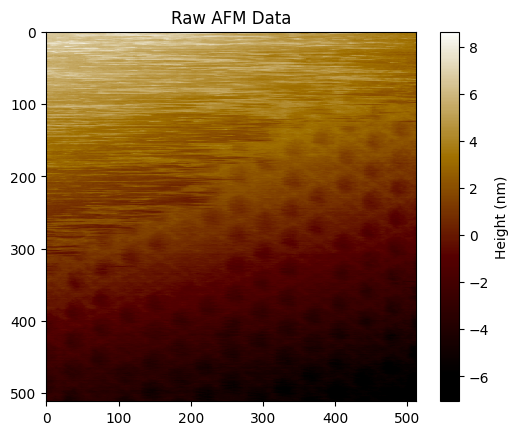

In [16]:
# Find repo root so demonstration data can be accessed
def find_repo_root(marker=".git"):
    """Walk up parent directories until we find the repo root (marked by .git folder)."""
    path = Path.cwd()
    for parent in [path] + list(path.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError("Could not find the repository root (no .git directory found).")

repo_root = find_repo_root()

# Demo path uses sample data from the test suite.
# To use your own data:
#   your_path = Path(r"C:\path\to\your\data.tiff")
#   demo_data = imread(your_path)
demo_path = repo_root / "tests" / "resources" / "sample_0.tiff"
demo_data = imread(demo_path)

plt.figure()
plt.title("Raw AFM Data")
plt.imshow(demo_data, cmap=AFM)
plt.colorbar(label="Height (nm)")
plt.show()


## 4. Apply Models

### Background Model

The background model is applied with the `level_ml_bg()` function within the `background_model` module. The function requires the loaded AFM data (NumPy array) and the path to the trained background model.

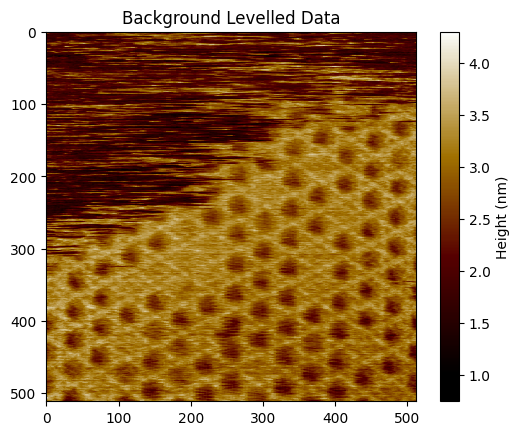

In [18]:
# Apply the background model

bg_levelled = level_ml_bg(demo_data, model_path=bg_model_path, line_order=3)
plt.figure()
plt.title("Background Levelled Data")
plt.imshow(bg_levelled, cmap=AFM)
plt.colorbar(label="Height (nm)")
plt.show()
